### Finite Element Method Example: Simple Tumor Growth PDE Model

Consider the following tumor growth model with spatial invasion & local proliferation:

$$
 \frac{\partial c(x,t)}{\partial t}
= D \nabla^2 c(x,t)
+ \rho \, c(x,t)\left(1 - \frac{c(x,t)}{K}\right). 
$$

- boundary condition: $\nabla c \cdot  n = 0$ on boundary (no flux)
- initial condition: Gaussian bump at time $0$

To set things up, run in bash (terminal): 

`conda install -c conda-forge fenics-dolfinx pyvista matplotlib`


In [3]:
## setup 

import numpy as np
from mpi4py import MPI

import ufl
from dolfinx import mesh, fem, plot
from dolfinx.fem.petsc import LinearProblem

import pyvista as pv

# Use one of: "static", "trame", "client"
# "static" is most robust for notebook environments.
pv.set_jupyter_backend("static")  # change to "trame", if want interactive widgets


pv.global_theme.window_size = [900, 600]
pv.global_theme.smooth_shading = True

print("PyVista backend:", pv.global_theme.jupyter_backend)

PyVista backend: static


In [4]:
## the initial condition: gaussian bump
def gaussian_ic(x, center=(0.25, 0.5), sigma=0.05, amp=0.6):
    cx, cy = center
    r2 = (x[0] - cx) ** 2 + (x[1] - cy) ** 2
    return amp * np.exp(-r2 / (2.0 * sigma ** 2))

## creat the mesh
def make_unit_square_mesh(nx=80, ny=80):
    return mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=mesh.CellType.triangle)


## convert the mesh object so we can visualize 
def function_to_pyvista_grid(u, name="c"):
    """
    Convert CG1 dolfinx Function u on a 2D mesh to a PyVista UnstructuredGrid.
    """
    domain = u.function_space.mesh
    topology, cell_types, geometry = plot.vtk_mesh(domain, domain.topology.dim)
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)
    grid.point_data[name] = u.x.array.real
    return grid


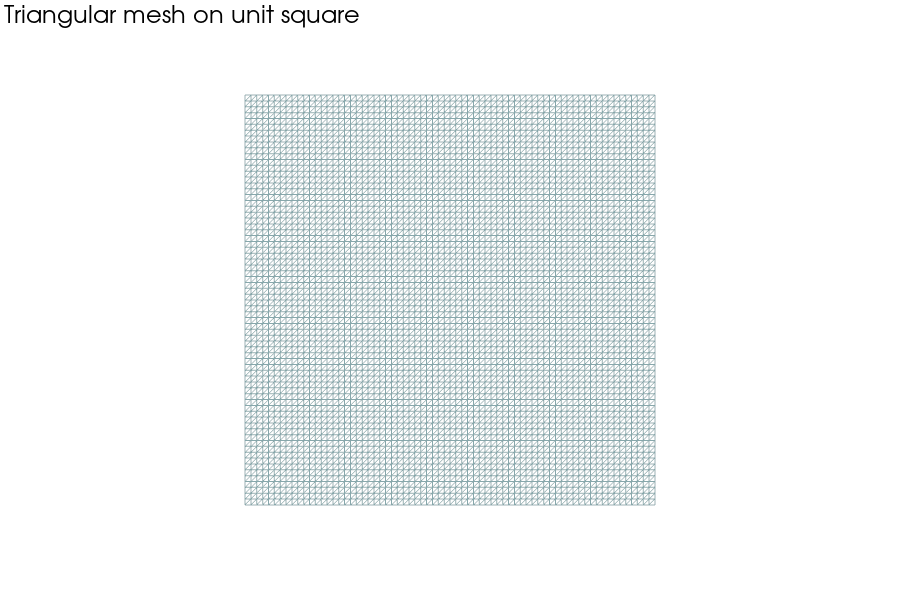

In [5]:
## visualize the triangular mesh 

domain = make_unit_square_mesh(nx=70, ny=70)

if domain.comm.rank == 0:
    topology, cell_types, geometry = plot.vtk_mesh(domain)
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)

    p = pv.Plotter()
    p.add_text("Triangular mesh on unit square", font_size=12)
    p.add_mesh(grid, style="wireframe", line_width=1)
    p.view_xy()
    p.show()

In [7]:
## Run the FEM to solve the PDE 

# -----------------------------
# PDE parameters
# -----------------------------
D = 1e-3
rho = 0.6
K = 1.0
Tfinal = 3.0

dt = 2.5e-3 # time step size 
nsteps = int(np.ceil(Tfinal / dt)) # then compute num. of time step 

## we will take snapshots at some discrete time points 
# Times to snapshot (in seconds)
snapshot_times = [0.0, 0.5, 1.0, 2.0, 3.0] # can change this to other time grids
snapshot_steps = {int(round(t / dt)) for t in snapshot_times}

# -----------------------------
# FEM space
# -----------------------------
V = fem.functionspace(domain, ("CG", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

u_n = fem.Function(V)
u_np1 = fem.Function(V)
u_np1.name = "c"

# Initial condition
u_n.interpolate(lambda x: gaussian_ic(x, center=(0.25, 0.5), sigma=0.05, amp=0.6))
u_np1.x.array[:] = u_n.x.array

# Boundary condition: natural Neumann (zero flux)
bcs = []

# Semi-implicit bilinear form (constant)
a = (1.0 / dt) * u * v * ufl.dx + D * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx

petsc_opts = {
    "ksp_type": "cg",
    "pc_type": "hypre",
    "ksp_rtol": 1e-10,
    "ksp_atol": 1e-12
}

# -----------------------------
# Store snapshots (rank 0 will visualize later)
# We'll store NumPy copies of nodal values.
# -----------------------------
snapshots = {}  # time -> nodal values array

if 0 in snapshot_steps:
    snapshots[0.0] = u_np1.x.array.copy()

t = 0.0
for step in range(1, nsteps + 1):
    t = min(step * dt, Tfinal)

    f_react = rho * u_n * (1.0 - u_n / K)
    L = (1.0 / dt) * u_n * v * ufl.dx + f_react * v * ufl.dx

    ## FEM turns PDE solve into a linear problem
    problem = LinearProblem(a, L, 
                            bcs=bcs, 
                            petsc_options=petsc_opts,
                            petsc_options_prefix="tumor_") 
    uh = problem.solve()

    u_np1.x.array[:] = uh.x.array
    u_np1.x.array[:] = np.clip(u_np1.x.array, 0.0, K)
    u_n.x.array[:] = u_np1.x.array

    if step in snapshot_steps:
        # Find the snapshot time closest to current t (for clean labeling)
        # Using rounding because dt might not hit times perfectly
        t_key = float(np.round(t, 2))
        snapshots[t_key] = u_np1.x.array.copy()

    if domain.comm.rank == 0 and step % 400 == 0:
        print(f"step {step}/{nsteps}, t={t:.3f}")

if domain.comm.rank == 0:
    print("Stored snapshots at times:", sorted(snapshots.keys()))

ld: warning: duplicate -rpath '/Library/anaconda3/envs/fenicsx/lib' ignored
ld: warning: duplicate -rpath '/Library/anaconda3/envs/fenicsx/lib' ignored
ld: warning: duplicate -rpath '/Library/anaconda3/envs/fenicsx/lib' ignored
ld: warning: duplicate -rpath '/Library/anaconda3/envs/fenicsx/lib' ignored


step 400/1200, t=1.000
step 800/1200, t=2.000
step 1200/1200, t=3.000
Stored snapshots at times: [0.0, 0.5, 1.0, 2.0, 3.0]


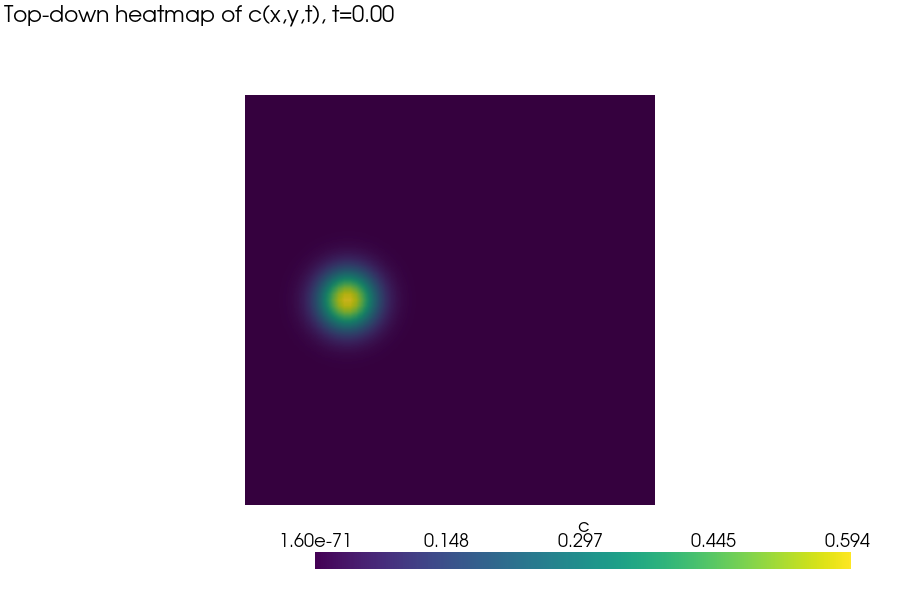

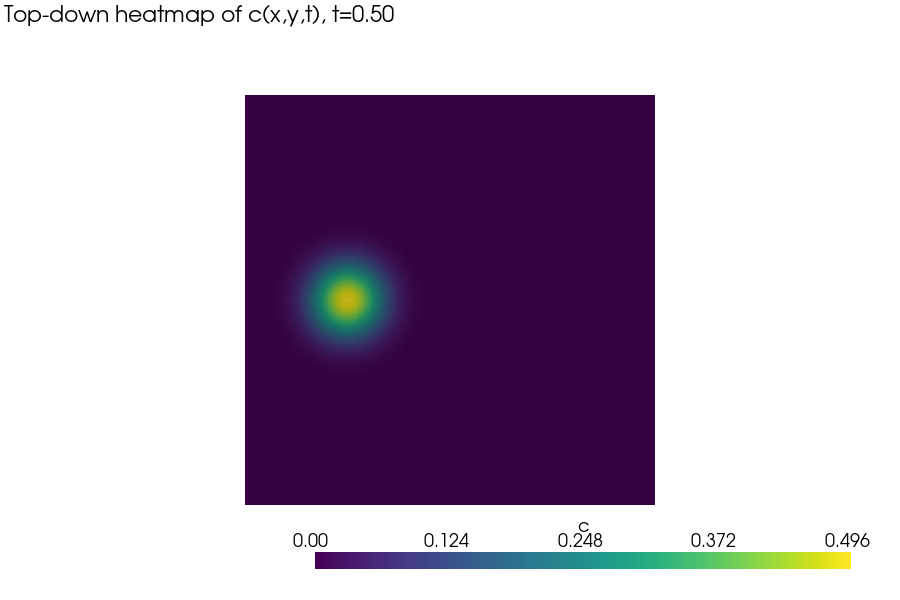

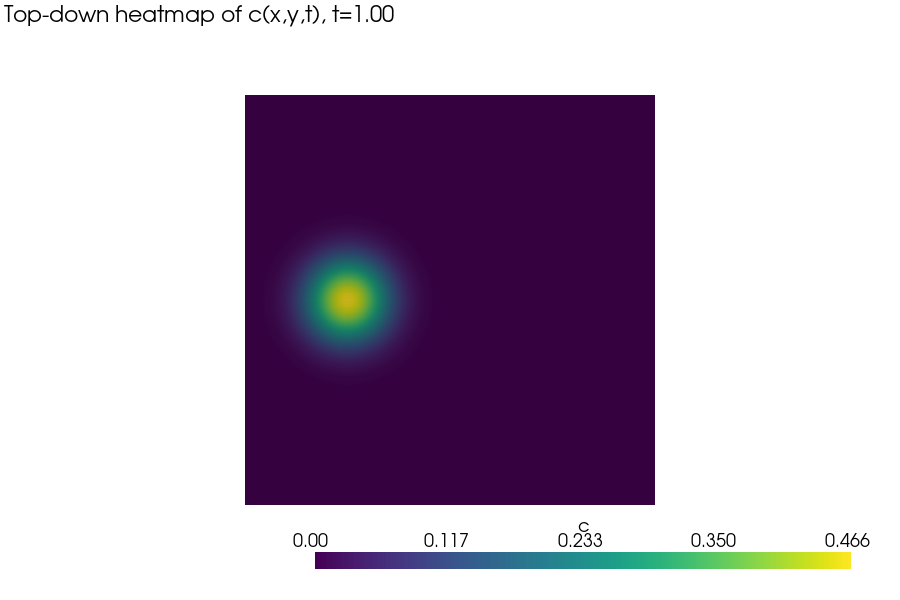

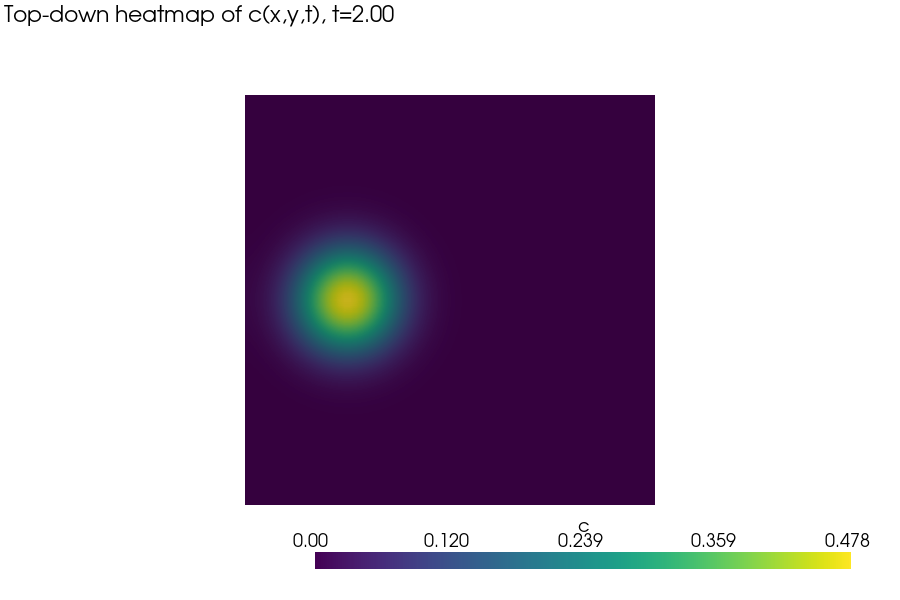

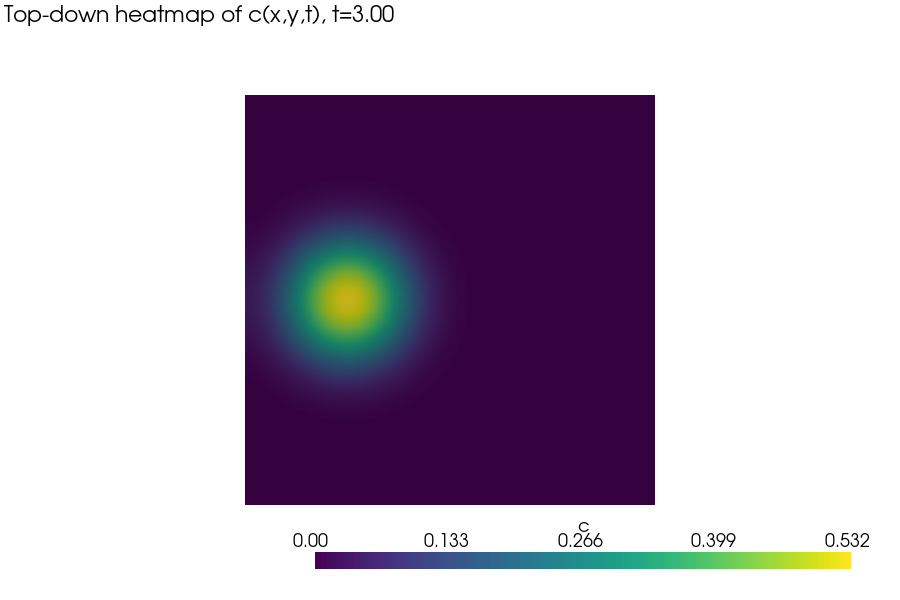

In [8]:
## 2D heatmap view of surface at time points 

import matplotlib.pyplot as plt

def show_heatmap_from_values(values, title, show_edges=False):
    """
    Render a top-down heatmap using PyVista's view_xy with scalar coloring.
    values: nodal values array for CG1.
    """
    if domain.comm.rank != 0:
        return

    u_tmp = fem.Function(V)
    u_tmp.x.array[:] = values

    grid = function_to_pyvista_grid(u_tmp, name="c")

    p = pv.Plotter()
    p.add_text(title, font_size=12)
    p.add_mesh(grid, scalars="c", show_scalar_bar=True, show_edges=show_edges)
    p.view_xy()
    p.show()

# Show heatmaps at stored snapshot times
if domain.comm.rank == 0:
    for t_key in sorted(snapshots.keys()):
        show_heatmap_from_values(
            snapshots[t_key],
            title=f"Top-down heatmap of c(x,y,t), t={t_key:.2f}",
            show_edges=False
        )


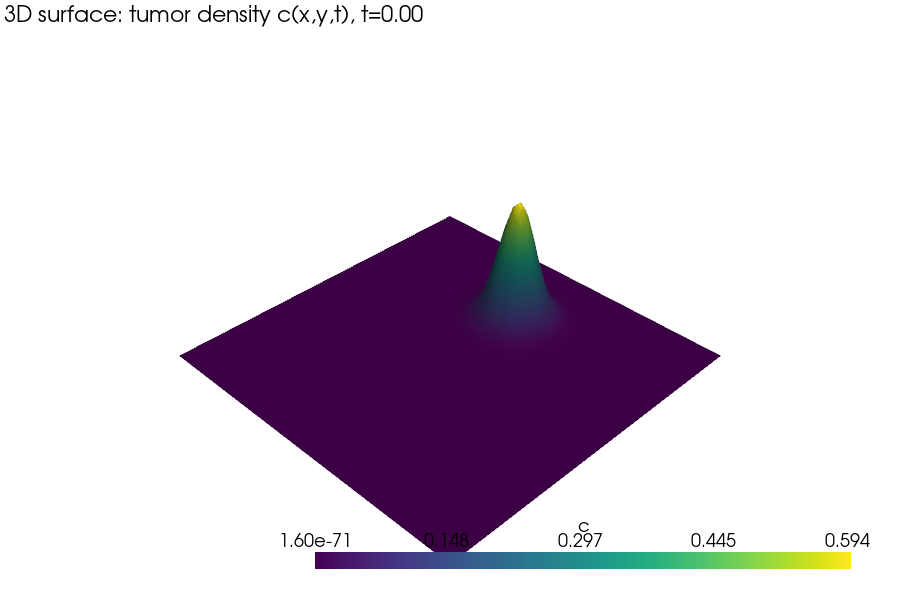

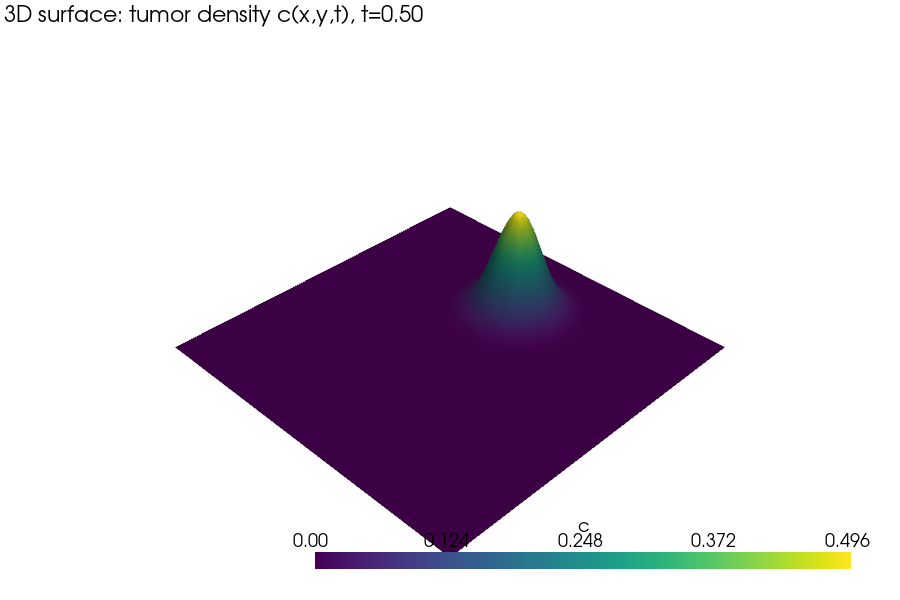

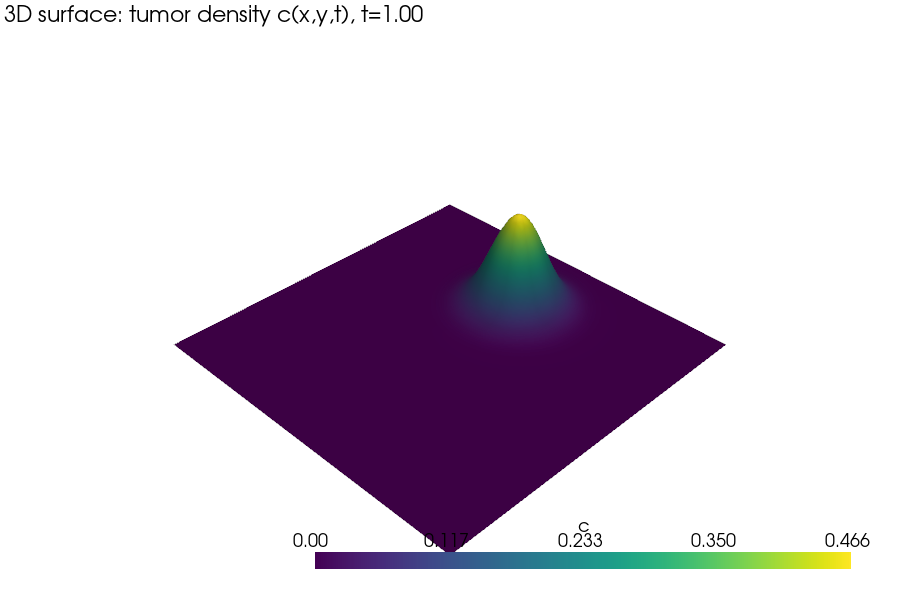

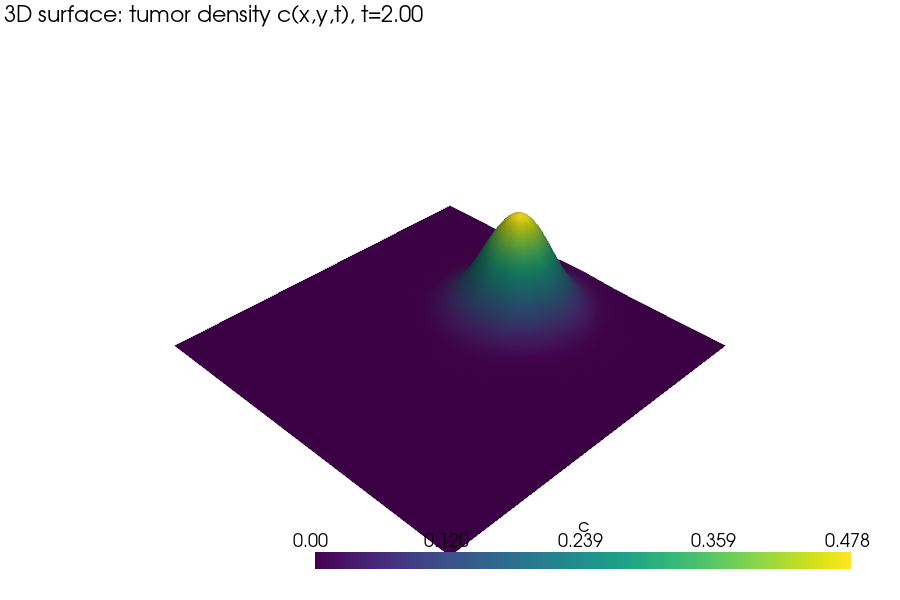

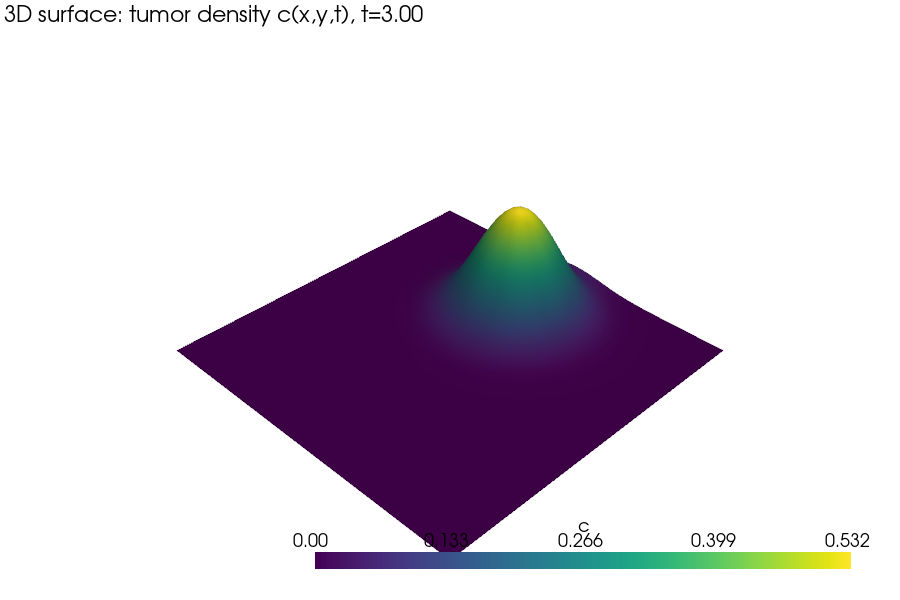

In [10]:
## try a 3D visualization


def show_3d_surface_from_values(values, title, zscale=0.30, show_edges=False):
    """
    Render a 3D surface by warping the 2D mesh in the z-direction by the scalar field.
    values: nodal values array for CG1 (same ordering as u.x.array)
    """
    if domain.comm.rank != 0:
        return

    # Reconstruct a Function from nodal values
    u_tmp = fem.Function(V)
    u_tmp.x.array[:] = values

    # Convert to PyVista grid and warp into 3D
    grid = function_to_pyvista_grid(u_tmp, name="c")
    warped = grid.warp_by_scalar("c", factor=zscale)

    p = pv.Plotter()
    p.add_text(title, font_size=12)
    p.add_mesh(warped, scalars="c", show_scalar_bar=True, show_edges=show_edges)
    p.view_isometric()
    p.show()

# Plot all snapshots in ascending time order
if domain.comm.rank == 0:
    for t_key in sorted(snapshots.keys()):
        show_3d_surface_from_values(
            snapshots[t_key],
            title=f"3D surface: tumor density c(x,y,t), t={t_key:.2f}",
            zscale=0.6,       # increase if want taller surface
            show_edges=False
        )